In [1]:
!nvidia-smi
!pip install ultralytics --quiet
!pip install opencv-python-headless --quiet

import ultralytics
ultralytics.checks()
from google.colab import drive
drive.mount('/content/drive')

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
Setup complete ✅ (12 CPUs, 167.1 GB RAM, 42.9/235.7 GB disk)
Mounted at /content/drive


In [2]:
import wandb
from google.colab import userdata
import os
os.environ['WANDB_API_KEY'] = userdata.get('WANDB_API_KEY')
wandb.init(project="Project_yolo11_tests_EV", entity="ertveh-4-lule-university-of-technology")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: ertveh-4 (ertveh-4-lule-university-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [3]:
import os
import zipfile

ZIP_PATH = '/content/drive/MyDrive/Training_data_10p.zip'
EXTRACT_DIR = '/content/dataset'

os.makedirs(EXTRACT_DIR, exist_ok=True)

print('Extracting...')
with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
    zf.extractall(EXTRACT_DIR)
print('Done.')

# Verify structure
for root, dirs, files in os.walk(EXTRACT_DIR):
    level = root.replace(EXTRACT_DIR, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:
        for f in files[:3]:
            print(f'{indent}  {f}')

Extracting...
Done.
dataset/
  Training_data_10p/
    data_10_full.yaml
    dataset/
      labels/
        train/
        val/
      images/
        train/
        val/


In [4]:
import yaml

dataset_config = {
    'path': '/content/dataset/Training_data_10p/dataset',
    'train': 'images/train',
    'val':   'images/val',
    'nc': 1,
    'names': ['car']
}

yaml_path = '/content/dataset.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(dataset_config, f, default_flow_style=False)

print(open(yaml_path).read())

names:
- car
nc: 1
path: /content/dataset/Training_data_10p/dataset
train: images/train
val: images/val



In [5]:
import cv2
import matplotlib.pyplot as plt
import random
import glob

def draw_yolo_boxes(img_path, label_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    if os.path.exists(label_path):
        with open(label_path) as f:
            for line in f:
                cls, cx, cy, bw, bh = map(float, line.strip().split())
                x1 = int((cx - bw/2) * w)
                y1 = int((cy - bh/2) * h)
                x2 = int((cx + bw/2) * w)
                y2 = int((cy + bh/2) * h)
                cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
    return img

image_files = glob.glob('/content/dataset/Training_data_10p/dataset/images/train/**/*.jpg', recursive=True) + \
              glob.glob('/content/dataset/Training_data_10p/dataset/images/train/**/*.png', recursive=True)

samples = random.sample(image_files, min(6, len(image_files)))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, img_path in zip(axes.flatten(), samples):
    label_path = img_path.replace('images', 'labels').rsplit('.', 1)[0] + '.txt'
    img = draw_yolo_boxes(img_path, label_path)
    ax.imshow(img)
    ax.set_title(os.path.basename(img_path), fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()
print(f'Total training images: {len(image_files)}')

Output hidden; open in https://colab.research.google.com to view.

In [6]:
from ultralytics import YOLO
from ultralytics.utils.callbacks import add_integration_callbacks
model = YOLO('yolov9c.pt')  # pretrained on COCO

add_integration_callbacks(model)



In [7]:
print(model)

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(128, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): RepNCSPELAN4(
        (cv1): Conv(
          (conv): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(128, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Sequential(
          (0): RepCSP(
            (cv1): Conv(
              (conv): Conv2d(64, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
              

In [8]:

results = model.train(
    data=yaml_path,
    epochs=100,
    imgsz=1280,
    batch=4,
    device=0,
    workers=2,
    project='/content/runs',
    name='yolov9c_nvd_10p_1280_frozen_bb',
    exist_ok=True,
    pretrained=True,
    freeze=10,        # only change from baseline
    patience=20,
    save=True,
    plots=True,
    cache='disk',
    amp=True
)

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov9c.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov9c_nvd_10p_1280_frozen_bb, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_

In [9]:
best_model = YOLO('/content/runs/yolov9c_nvd_10p_1280_frozen_bb/weights/best.pt')

metrics = best_model.val(data=yaml_path, imgsz=1280, device=0)

print(f"mAP@50:     {metrics.box.map50:.4f}")
print(f"mAP@50-95:  {metrics.box.map:.4f}")
print(f"Precision:  {metrics.box.mp:.4f}")
print(f"Recall:     {metrics.box.mr:.4f}")

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
YOLOv9c summary (fused): 156 layers, 25,320,019 parameters, 0 gradients, 102.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2047.7±1106.1 MB/s, size: 515.1 KB)
val: Scanning /content/dataset/Training_data_10p/dataset/labels/val.cache... 1203 images, 1323 backgrounds, 3 corrupt: 100% ━━━━━━━━━━━━ 2526/2526 815.0Mit/s 0.0s
val: /content/dataset/Training_data_10p/dataset/images/val/frame_1944.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0105      1.0112]
val: /content/dataset/Training_data_10p/dataset/images/val/frame_2238.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0119]
val: /content/dataset/Training_data_10p/dataset/images/val/frame_381.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0116]
                 Class     Images  Instances      Box(P          R   

In [10]:
import shutil, os

DRIVE_OUTPUT = '/content/drive/MyDrive/D7047E Project Datasets/yolov9c_results'
os.makedirs(DRIVE_OUTPUT, exist_ok=True)

shutil.copy('/content/runs/yolov9c_nvd_10p_1280_frozen_bb/weights/best.pt',
            os.path.join(DRIVE_OUTPUT, 'yolov9c_10p_frozen_best.pt'))
shutil.copy('/content/runs/yolov9c_nvd_10p_1280_frozen_bb/weights/last.pt',
            os.path.join(DRIVE_OUTPUT, 'yolov9c_10p_frozen_last.pt'))
shutil.copy('/content/runs/yolov9c_nvd_10p_1280_frozen_bb/results.csv',
            os.path.join(DRIVE_OUTPUT, 'yolov9c_10p_frozen_results.csv'))

print('Saved.')

Saved.


Found 1 detection(s) in: /content/dataset/Training_data_10p/dataset/images/val/frame_2381.jpg


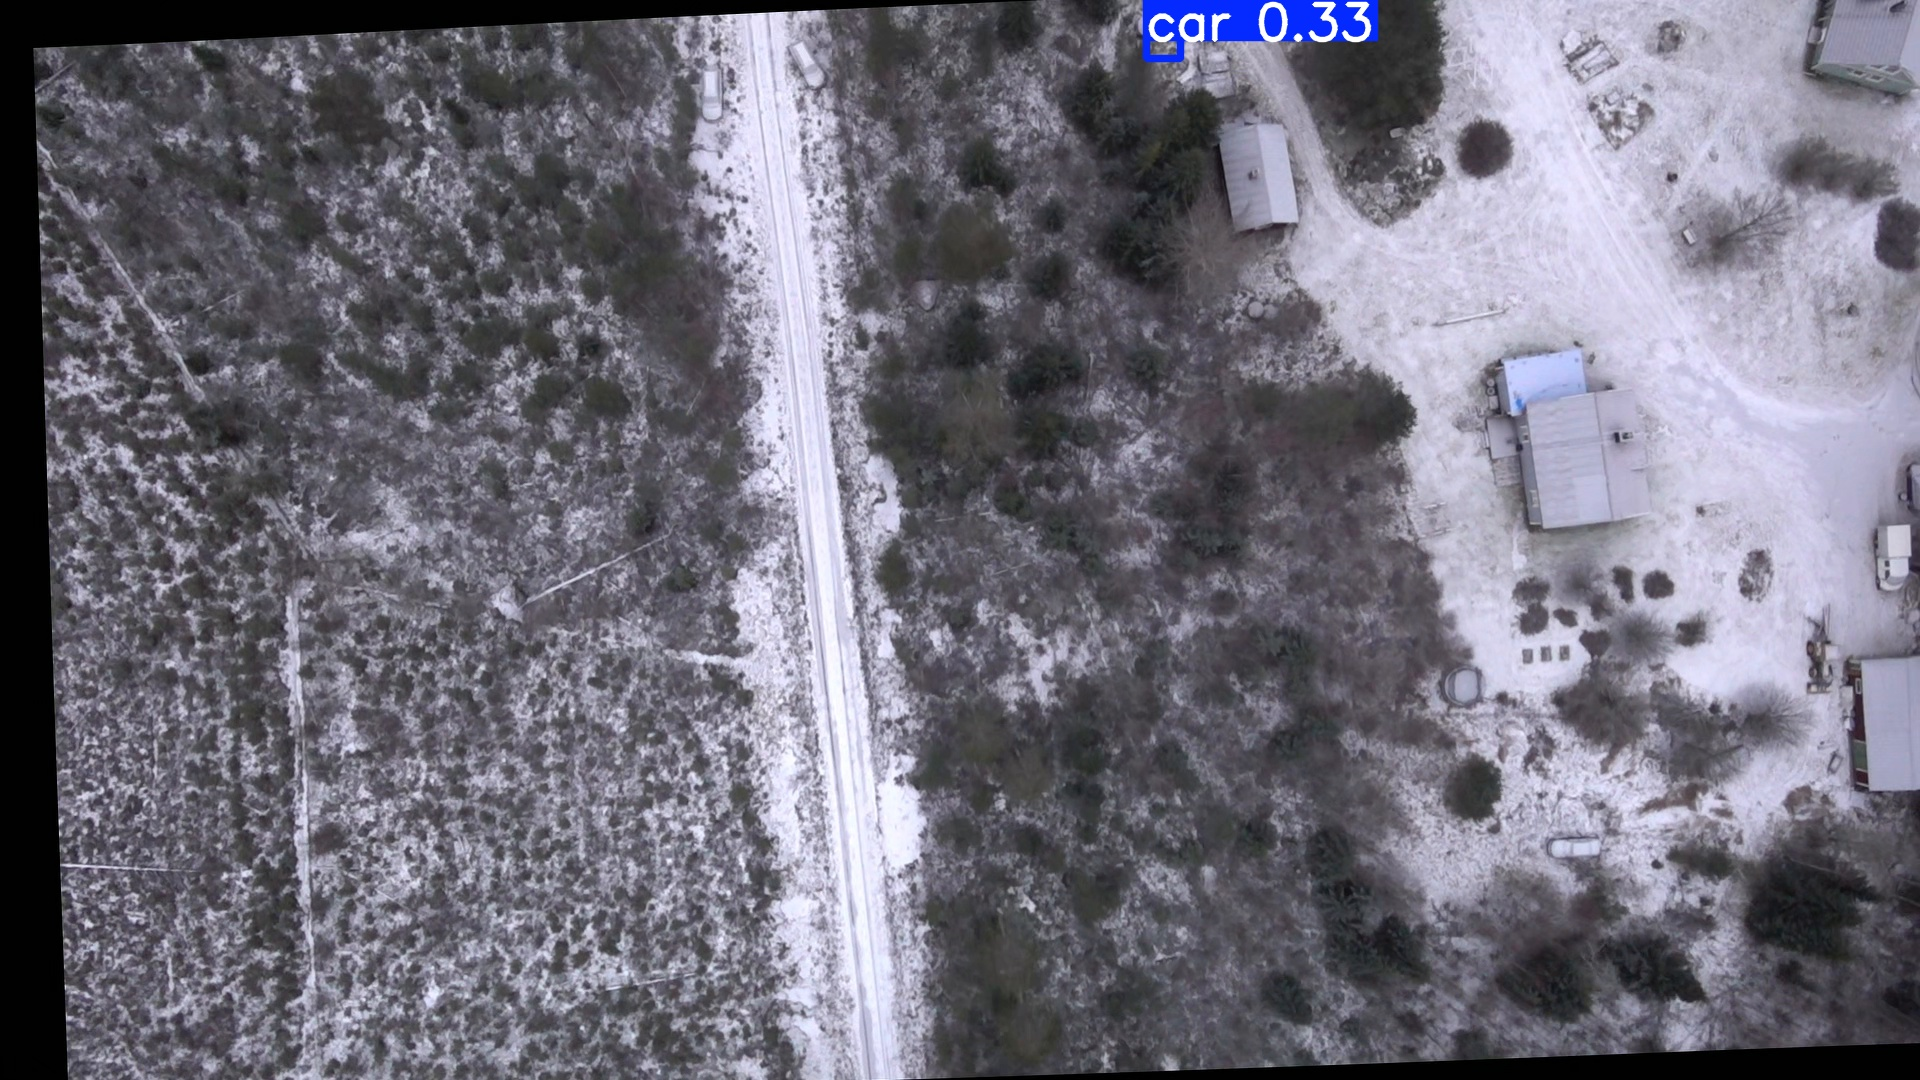

In [11]:
from ultralytics import YOLO
import glob
import random

# Load frozen backbone best weights
model = YOLO('/content/runs/yolov9c_nvd_10p_1280_frozen_bb/weights/best.pt')

# Pick a random val image with detections
image_files = glob.glob('/content/dataset/Training_data_10p/dataset/images/val/**/*.jpg', recursive=True) + \
              glob.glob('/content/dataset/Training_data_10p/dataset/images/val/**/*.png', recursive=True)

for img_path in random.sample(image_files, 20):
    results = model(img_path, imgsz=1280, conf=0.25, verbose=False)
    if len(results[0].boxes) > 0:
        print(f'Found {len(results[0].boxes)} detection(s) in: {img_path}')
        results[0].save(filename='/content/prediction_frozen.jpg')
        break

from IPython.display import Image
Image('/content/prediction_frozen.jpg')